# 🔍 Credit Card Fraud Detection — Exploratory Data Analysis

**Objective:** Understand the dataset structure, visualize class imbalance, and explore feature distributions to inform our modeling strategy.

---

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Features:** 284,807 transactions | 492 fraud cases | V1–V28 (PCA) + Time + Amount + Class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.edgecolor':   '#334155',
    'grid.color':       '#334155',
    'axes.grid':        True,
    'font.size':        11,
})
sns.set_theme(style='darkgrid', palette='muted')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Overview

In [2]:
df = pd.read_csv('../data/creditcard.csv')

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum().sum(), 'total missing')
print('\nClass distribution:')
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")

Shape: (284807, 31)

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
0 total missing

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [3]:
df.describe().round(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


## 2. Class Imbalance Visualization

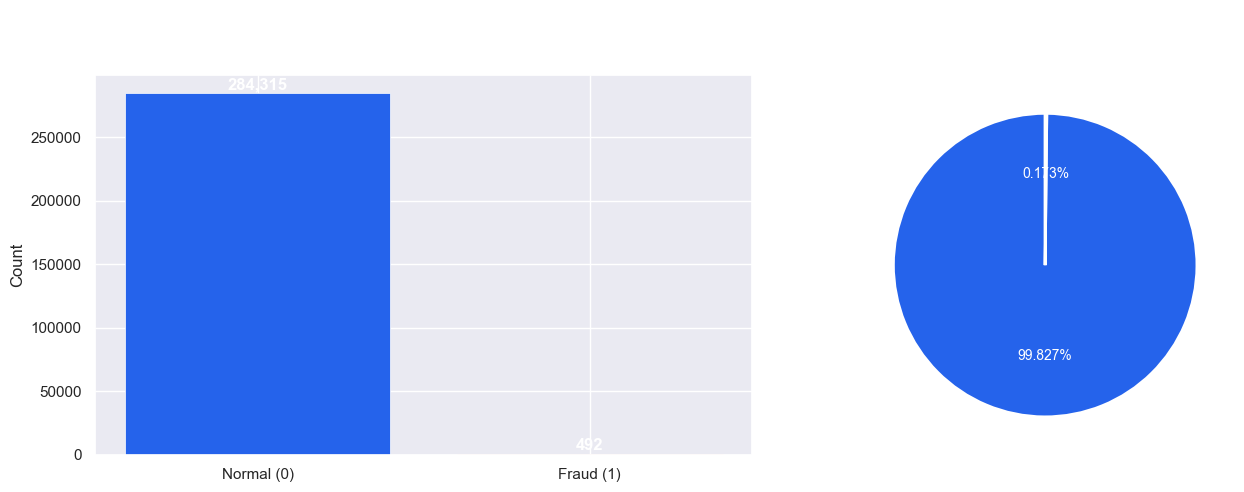

Imbalance ratio — Normal:Fraud = 284315:492 = 578:1


In [4]:
class_counts = df['Class'].value_counts()
labels = ['Normal (0)', 'Fraud (1)']
colors = ['#2563EB', '#DC2626']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance in Credit Card Fraud Dataset', fontsize=15, fontweight='bold', color='white')

# Bar chart
bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', color='white')
axes[0].set_title('Transaction Count by Class', color='white')
axes[0].set_ylabel('Count')

# Pie chart
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1].pie(
    class_counts.values,
    labels=[f'{l}\n({v:,})' for l, v in zip(labels, class_counts.values)],
    colors=colors,
    autopct='%1.3f%%',
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'color': 'white', 'fontsize': 10},
)
axes[1].set_title('Fraud vs Normal Proportion', color='white')

plt.tight_layout()
plt.savefig('../data/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio — Normal:Fraud = {class_counts[0]}:{class_counts[1]} = {class_counts[0]/class_counts[1]:.0f}:1')

## 3. Transaction Amount Distribution

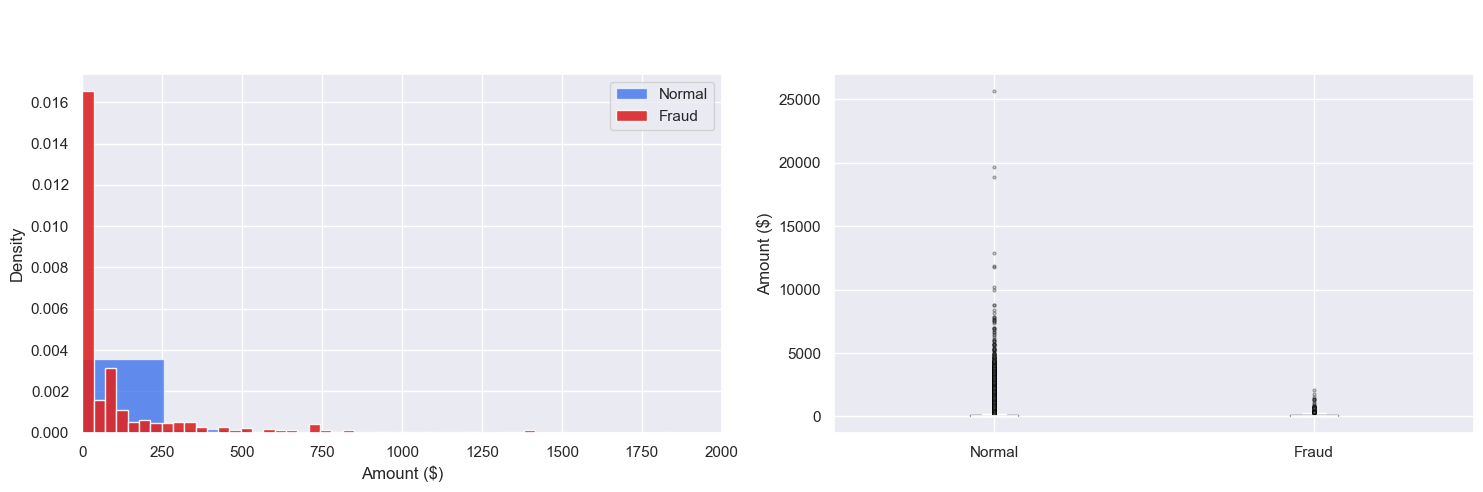

Normal — Mean: $88.29 | Median: $22.00 | Max: $25691.16
Fraud  — Mean: $122.21  | Median: $9.25  | Max: $2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold', color='white')

# Histogram
axes[0].hist(df[df['Class']==0]['Amount'], bins=100, color='#2563EB', alpha=0.7, label='Normal', density=True)
axes[0].hist(df[df['Class']==1]['Amount'], bins=60, color='#DC2626', alpha=0.9, label='Fraud', density=True)
axes[0].set_title('Amount Distribution (density)', color='white')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 2000)

# Box plot
fraud_amounts  = df[df['Class']==1]['Amount']
normal_amounts = df[df['Class']==0]['Amount']
bp = axes[1].boxplot(
    [normal_amounts, fraud_amounts],
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], ['#2563EB', '#DC2626']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Amount Box Plot: Fraud vs Normal', color='white')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

print(f"Normal — Mean: ${normal_amounts.mean():.2f} | Median: ${normal_amounts.median():.2f} | Max: ${normal_amounts.max():.2f}")
print(f"Fraud  — Mean: ${fraud_amounts.mean():.2f}  | Median: ${fraud_amounts.median():.2f}  | Max: ${fraud_amounts.max():.2f}")

## 4. Time Distribution of Fraud

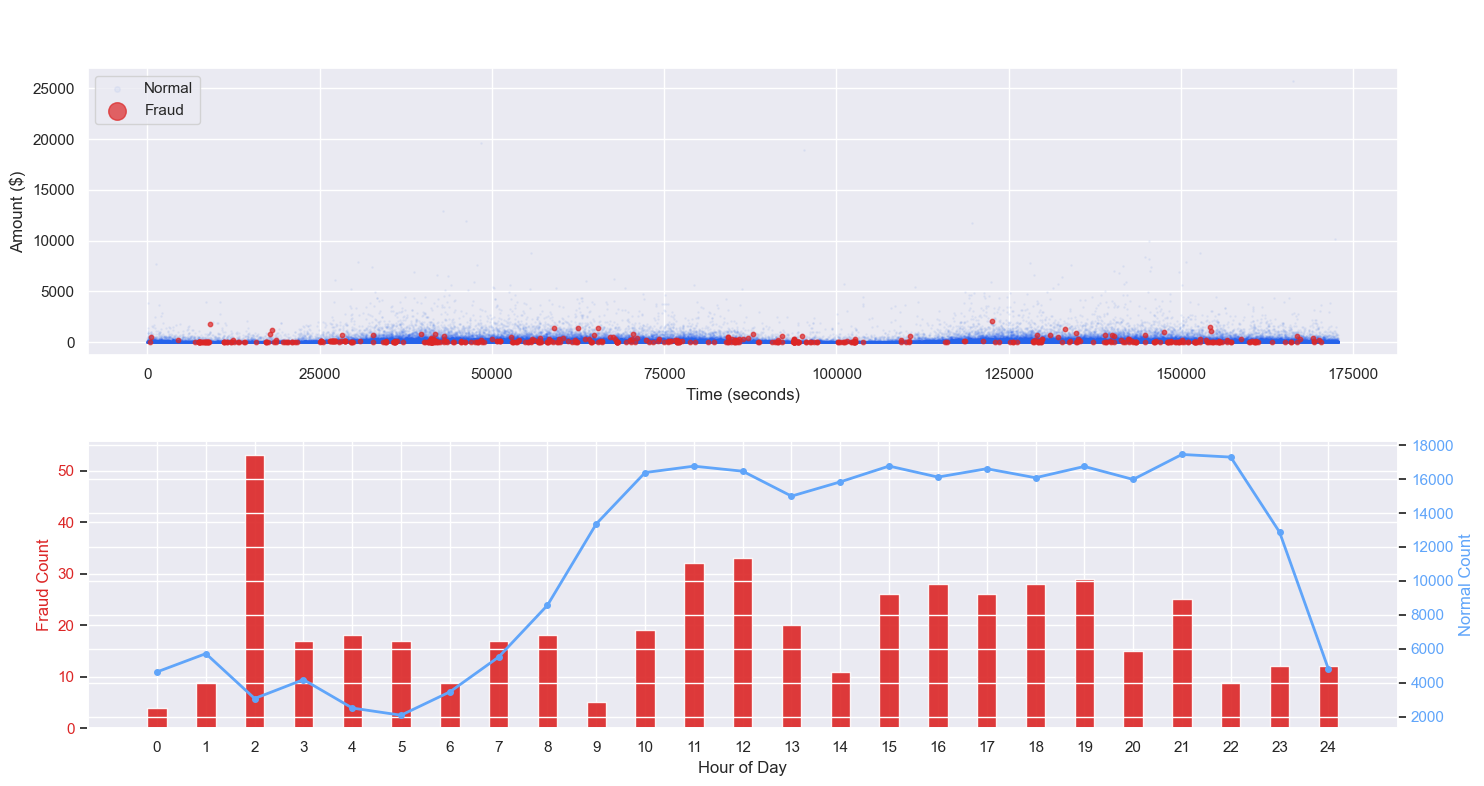

In [6]:
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Temporal Distribution of Transactions', fontsize=14, fontweight='bold', color='white')

# All transactions over time
axes[0].scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
                alpha=0.05, s=1, color='#2563EB', label='Normal')
axes[0].scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
                alpha=0.7, s=10, color='#DC2626', label='Fraud')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amount ($)')
axes[0].set_title('Transaction Timeline (Fraud in Red)', color='white')
axes[0].legend(markerscale=4)

# Fraud by hour
hour_fraud  = df[df['Class']==1]['Hour'].round(0).value_counts().sort_index()
hour_normal = df[df['Class']==0]['Hour'].round(0).value_counts().sort_index()

axes[1].bar(hour_fraud.index, hour_fraud.values, color='#DC2626', alpha=0.9, label='Fraud', width=0.4, align='center')
ax2 = axes[1].twinx()
ax2.plot(hour_normal.index, hour_normal.values, color='#60A5FA', linewidth=2, marker='o', markersize=4, label='Normal')
ax2.set_ylabel('Normal Count', color='#60A5FA')
ax2.tick_params(axis='y', labelcolor='#60A5FA')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Count', color='#DC2626')
axes[1].tick_params(axis='y', labelcolor='#DC2626')
axes[1].set_title('Fraud and Normal Transactions by Hour of Day', color='white')
axes[1].set_xticks(range(0, 25))

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

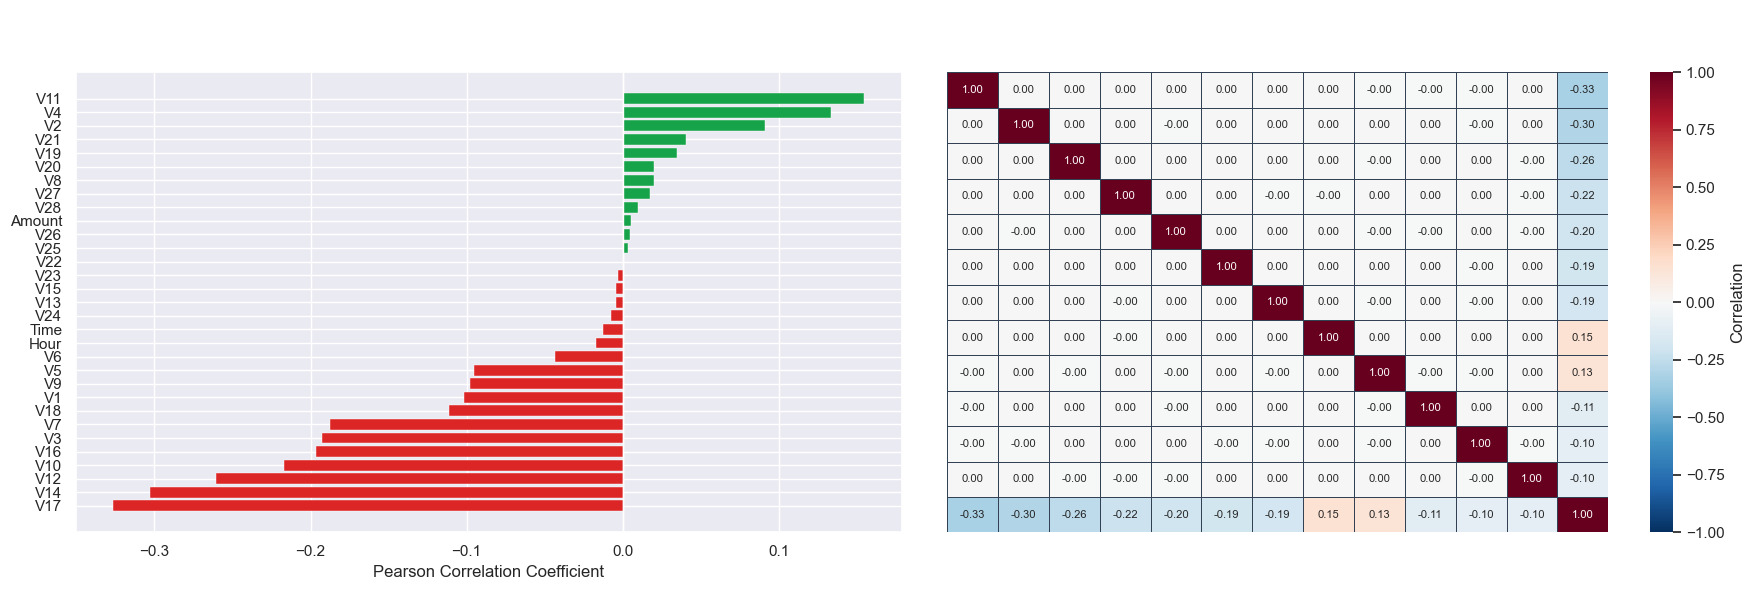

In [7]:
# Focus on correlations with the target Class variable
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', color='white')

# Correlation with Class (target)
colors_corr = ['#DC2626' if x < 0 else '#16A34A' for x in correlations.values]
axes[0].barh(correlations.index, correlations.values, color=colors_corr, edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='white', linewidth=1)
axes[0].set_title('Feature Correlation with Class (Fraud)', color='white')
axes[0].set_xlabel('Pearson Correlation Coefficient')

# Full heatmap (top features only)
top_features = list(correlations.abs().nlargest(12).index) + ['Class']
corr_matrix = df[top_features].corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_matrix,
    ax=axes[1],
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='#334155',
    cbar_kws={'label': 'Correlation'},
)
axes[1].set_title('Correlation Heatmap (Top Features)', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

## 6. Fraud vs Normal Feature Distributions

In [1]:
# Compare distributions of top correlated features
top_5_corr = correlations.abs().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribution of Top Correlated Features: Fraud vs Normal', 
             fontsize=13, fontweight='bold', color='white')

for i, feat in enumerate(top_5_corr):
    normal_vals = df[df['Class']==0][feat]
    fraud_vals  = df[df['Class']==1][feat]
    
    axes[i].hist(normal_vals, bins=50, alpha=0.6, color='#2563EB', density=True, label='Normal')
    axes[i].hist(fraud_vals,  bins=30, alpha=0.8, color='#DC2626', density=True, label='Fraud')
    axes[i].set_title(feat, color='white')
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].set_ylabel('Density')
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

NameError: name 'correlations' is not defined

## 7. Statistical Summary by Class

In [ ]:
comparison = df.groupby('Class')[top_5_corr + ['Amount']].agg(['mean', 'std', 'median']).round(4)
comparison.index = ['Normal', 'Fraud']
print('Statistical Summary (Fraud vs Normal)')
comparison

## 8. Key Insights Summary

| Insight | Finding |
|---|---|
| **Class Imbalance** | 99.83% normal, 0.17% fraud → SMOTE oversampling required |
| **Amount** | Fraud median ($22) < Normal median ($22) — small amounts dominate fraud |
| **Time** | Fraud concentrated in early morning hours (0–6 AM) |
| **Top Features** | V14, V10, V12, V4, V11 have highest correlation with fraud |
| **Missing Data** | None — dataset is clean |
| **Feature Scale** | V1–V28 are PCA-scaled; Amount and Time need scaling |

**Recommended Modeling Strategy:**
1. Scale `Amount` and `Time`
2. Apply SMOTE to balance classes in training set
3. Use ROC-AUC and Recall as primary metrics (not accuracy)
4. Ensemble models (Random Forest, Gradient Boosting) expected to outperform Logistic Regression